# Requirements figure: dark-matter reach versus astrometric capability

Produces **`figs/requirements.pdf`**, for **both** benchmark systems on one set of
axes. This figure is *not* in the published paper --- it was cut from the final
draft --- but it is kept here because it is the clearest summary of how the reach
of Tab. `tab:bottomline` scales with the astrometric precision.

Peak acceleration-channel SNR evaluated along the fiducial $\Lambda$CDM
$\rho_s(M_\mathrm{L})$ prediction (the dashed relation of `figs/SNR.pdf`), versus
the per-epoch relative astrometric precision $\sigma_{\delta\theta}$, for the
fiducial $\tau = 10\,$yr, $N = 300$ campaign. Vertical bands mark representative
current and planned astrometric capabilities; the EPIC band is drawn in the wine
tint of the B1422+231 curves, because intensity interferometry needs a source far
brighter than the known cluster lenses, so that band applies to the galaxy lens
only and *not* to the higher cluster-lens curve that passes through it.

Three curves:

- **B1422+231 (with stellar microlensing residual)** --- includes the worst-case
  post-subtraction stellar microlensing residual of Sec. III C: the unfitted-star
  bound plus the fitted-star subtraction residual, evaluated at image A (the case
  studied in the companion paper, rescaled to the survey parameters here) and
  doubled for the differential pair. The per-epoch precision tracks the
  intensity-interferometric fit quality, so the instrumental floor and the
  fitted-star residual both scale as $\sigma_{\delta\theta}^2$, while the
  unfitted-star bound scales as $\sigma_{\delta\theta}^3$ (via
  $\theta_\mathrm{fit} \propto \sigma_{\delta\theta}^{-1/2} N^{1/4}$):

  $$\mathrm{SNR} = \frac{S_\mathrm{CDM}}{(\mathrm{instr} + 2\,\mathrm{fitted}_A)\,s^2 + 2\,\mathrm{unfitted}_A\,s^3}, \qquad s = \frac{\sigma_{\delta\theta}}{0.1\,\mu\mathrm{as}}.$$

- **B1422+231 (no microlensing)** --- instrument-limited reach
  ($\mathrm{SNR} \propto \sigma_{\delta\theta}^{-2}$) for certifiably star-free
  epochs and images, and for upper limits.

- **SDSS J1029+2623** (cluster lens) --- the stellar background is negligible
  ($\kappa_* \approx 0.003$), so only the instrumental scaling applies. Its curve
  sits a factor $\approx5$ above the star-free galaxy-lens curve, because the
  bright B,C pair straddles the tangential critical curve ($|B^\mathrm{I}_\mathrm{t}|\approx22.6$
  against $7.5$--$10.2$ at B1422+231): at the near-equal sweep rates
  $\widetilde{\mu}^\mathrm{I}\approx1\,\mathrm{\mu as/yr}$ of the two systems, the
  extra $B^2$ prefactor of Eq. (observable_2_parametric) is what remains of the
  $B^6$ scaling once the cluster's slower transverse velocity is paid for.

A vertical dashed line marks the far more modest precision at which the image
proper motion $\widetilde{\mu}^\mathrm{I} = 1\,\mathrm{\mu as/yr}$ is itself
measured at SNR = 1 (50 $\mu$as) --- the measurement that reduces the macromodel
dependence of the acceleration forecast from $B^6$ to $B^2$ (Sec. III B).

**Inputs.** This notebook is a thin, fast summary layer: the signal and noise
budget at the reference precision is computed in `sensitivity.ipynb` (both parts)
and `impact_numbers.py`, and is hard-coded below with provenance comments. Change
those numbers here only in step with a re-run of `sensitivity.ipynb`.

*Runtime: seconds.*

## Setup and budget inputs

In [1]:
from preamble import *

colors = sns.color_palette(xgfs_fancy6)

# ---- galaxy lens B1422+231, at the reference sigma_delta_theta = 0.1 muas ----
# Peak signal along the fiducial CDM rho_s(M_L) relation, best pair (A,B), at
# M_L = 9.7e-5 Msun, in muas^2/yr^4. Equals SNR_B1422_clean x instr; from impact_numbers.py.
S_CDM = 3.17e-5
# Noise budget at sigma_delta_theta = 0.1 muas [muas^2/yr^4]: the instrumental floor of
# Eq. (noise_2) and the worst-case image-A stellar residual, split into its fitted-star and
# unfitted-star parts because they scale differently with precision (see below). Both are
# doubled for the differential pair. From sensitivity.ipynb / impact_numbers.py.
instr = 2.4e-6
fitted_A = 8.83e-6
unfitted_A = 3.7e-6
SNR_B1422_clean = 13.2     # instrument-limited (certifiably star-free) SNR at 0.1 muas

# ---- cluster lens SDSS J1029+2623, at the reference sigma_delta_theta = 1 muas ----
SNR_J1029_at_1p0 = 0.67    # f_sub = 0.5, no stellar cap (impact_numbers.py); v_eff = 552 km/s
                           # including the moving-clump member-halo term at f_gal = 0.2

## SNR versus precision

In [2]:
sig = np.logspace(-2, 3, 400)   # sigma_delta_theta [muas]
s = sig / 0.1                   # precision relative to the EPIC reference
snr_B_star = S_CDM / ((instr + 2*fitted_A)*s**2 + 2*unfitted_A*s**3)
snr_B_clean = SNR_B1422_clean * (0.1/sig)**2
snr_J = SNR_J1029_at_1p0 * (1.0/sig)**2

# thresholds where SNR = 1
sig_B_star = sig[np.argmin(np.abs(snr_B_star - 1))]
sig_B_clean = 0.1*np.sqrt(SNR_B1422_clean)
sig_J1 = 1.0*np.sqrt(SNR_J1029_at_1p0)
print('SNR=1 thresholds: B1422 %.3f muas (with stellar) | %.2f muas (clean) | J1029 %.2f muas'
      % (sig_B_star, sig_B_clean, sig_J1))
print('SNR at fiducial 0.1 muas, with stellar: %.2f' % snr_B_star[np.argmin(np.abs(sig-0.1))])
print('SNR at 0.03 muas, with stellar: %.2f' % snr_B_star[np.argmin(np.abs(sig-0.03))])

# ---- proper-motion reference line ---------------------------------------------------
# Precision at which the magnified image motion itself, mu_tilde^I = 1 muas/yr (the value
# of the bright B,C pair of the cluster lens; Sec. sec:cluster), is measured at SNR = 1.
# The proper-motion measurement noise of Eq. (est_1_var) is sigma_mu^2 = 12 sigma^2 Dt/tau^3
# with Dt = tau/N, i.e. sigma_mu = sigma_delta_theta sqrt(12/N)/tau, so setting
# sigma_mu = mu_ref gives sigma_delta_theta = mu_ref tau sqrt(N/12).  Measuring mu_tilde^I
# is what turns the B^6 macromodel dependence of the acceleration forecast into B^2
# (Sec. sec:signals). It is far easier than detecting the acceleration: 50 muas is 60x
# coarser than the cluster-lens threshold and ~500x coarser than the galaxy-lens one.
tau_yr, N_obs = 10.0, 300
mu_ref = 1.0                                     # muas/yr
sig_mu1 = mu_ref * tau_yr * np.sqrt(N_obs/12)    # = 50 muas
print('mu_tilde = %.2g muas/yr measured at SNR=1 for sigma_delta_theta = %.3g muas'
      % (mu_ref, sig_mu1))

SNR=1 thresholds: B1422 0.107 muas (with stellar) | 0.36 muas (clean) | J1029 0.82 muas
SNR at fiducial 0.1 muas, with stellar: 1.14
SNR at 0.03 muas, with stellar: 15.88
mu_tilde = 1 muas/yr measured at SNR=1 for sigma_delta_theta = 50 muas


## Figure  →  `figs/requirements.pdf`

saved ../figs/requirements.pdf


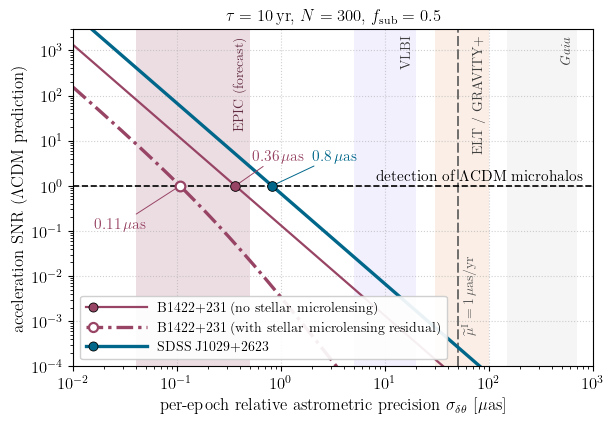

In [3]:
from matplotlib.legend_handler import HandlerLine2D

fig, ax = plt.subplots(1, 1, figsize=(6.3, 4.4))

# The two B1422+231 curves share one color, the wine of the galaxy lens, and are told apart
# by weight and dashing: the stellar-limited one is the heavy dash-dot line, the
# instrument-only one the thin solid line.
c_star  = np.asarray(colors[4])
c_clean = c_star          # same wine: both curves describe the same target
c_J     = np.asarray(colors[3])
ls_star = (0, (5, 1.5, 1, 1.5))

# capability bands (representative per-epoch relative astrometric precision); x_lab is the
# label position, nudged off the band's geometric center where a curve or line collides.
# EPIC is given the wine tint of the B1422+231 curves instead of a color of its own: it is
# an optical intensity interferometer, so it reaches only sources bright enough for that
# technique --- the galaxy lens, not the far fainter known cluster lenses (Sec.
# sec:prospects). Its sub-muas band is therefore to be read against the wine curves alone,
# and the higher teal cluster curve underneath it is *not* an EPIC target.
c_lab = (0.25, 0.25, 0.25)
bands = [
    (0.04, 0.5,  r'EPIC (forecast)',    c_star,    0.8 * 0.5,  0.65 * c_star),
    (5,    20,   r'VLBI',               colors[1], 0.8 * 20,   c_lab),
    (30,   100,  r'ELT / GRAVITY$+$',   colors[2], 0.8 * 100,  c_lab),
    (150,  700,  r'\textit{Gaia}',      colors[6], 0.8 * 700,  c_lab),
]
for lo, hi, lab, c, x_lab, c_txt in bands:
    ax.axvspan(lo, hi, color=c, alpha=0.18, lw=0)
    ax.text(x_lab, 2.2e3, lab, rotation=90, fontsize=10,
            ha='center', va='top', color=c_txt)

# precision at which the image proper motion mu_tilde^I = 1 muas/yr is itself measured at
# SNR = 1 (previous cell): the far easier measurement that calibrates B^I. The label is
# anchored just above the lowest curve at this abscissa (snr_J = 1.9e-4 at 59 muas).
ax.axvline(sig_mu1, color=(0.35, 0.35, 0.35), lw=1.2, ls=(0, (6, 2)))
ax.text(sig_mu1*1.1, 5e-4, r'$\widetilde{\mu}^\mathrm{I} = 1\,\mathrm{\mu as/yr}$',
        rotation=90, fontsize=10, ha='left', va='bottom', color=(0.35, 0.35, 0.35))

ax.plot(sig, snr_B_clean, color=colors[4], lw=1.6, ls='solid',
        label=r'B1422$+$231 (no stellar microlensing)')
ax.plot(sig, snr_B_star, color=colors[4], lw=2.4, ls=ls_star,
        label=r'B1422$+$231 (stellar microlensing residual)')
ax.plot(sig, snr_J, color=colors[3], lw=2.4,
        label=r'SDSS J1029$+$2623')

ax.axhline(1, color='k', lw=1.2, ls='dashed')
ax.text(8.01e2, 1.1, r'detection of $\Lambda$CDM microhalos', fontsize=11,
        ha='right', va='bottom', color='k')

# SNR = 1 thresholds: filled markers for the instrument-only curves, open marker for the
# curve that carries the stellar microlensing residual.
for x, c in [(sig_B_clean, c_clean), (sig_J1, c_J)]:
    ax.plot([x], [1], marker='o', ms=7, color=c, mec='k', mew=0.6, zorder=5)
ax.plot([sig_B_star], [1], marker='o', ms=7, color='w', mec=c_star, mew=1.6, zorder=5)
# white boxes behind the threshold labels so they can sit on top of the curves
lab_box = dict(boxstyle='square,pad=0.12', facecolor='white', edgecolor='none', alpha=0)
ax.annotate(r'$%.1f\,\mathrm{\mu as}$' % sig_J1, xy=(sig_J1, 1), xytext=(2.0, 3.2),
            fontsize=11, color=colors[3], ha='left', va='bottom', bbox=lab_box,
            arrowprops=dict(arrowstyle='-', color=colors[3], lw=0.7))
ax.annotate(r'$%.2f\,\mathrm{\mu as}$' % sig_B_clean, xy=(sig_B_clean, 1), xytext=(0.52, 3.2),
            fontsize=11, color=colors[4], ha='left', va='bottom', bbox=lab_box,
            arrowprops=dict(arrowstyle='-', color=colors[4], lw=0.7))
ax.annotate(r'$%.2f\,\mathrm{\mu as}$' % sig_B_star, xy=(sig_B_star, 1), xytext=(1.6e-2, 0.10),
            fontsize=11, color=colors[4], ha='left', va='bottom', bbox=lab_box,
            arrowprops=dict(arrowstyle='-', color=colors[4], lw=0.7))

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(1e-2, 1e3); ax.set_ylim(1e-4, 3e3)
ax.set_xlabel(r'per-epoch relative astrometric precision $\sigma_{\delta\theta}~[\mathrm{\mu as}]$')
ax.set_ylabel(r'acceleration SNR ($\Lambda$CDM prediction)')
# Proxy handles, so the legend also carries the filled/open marker convention. The two
# B1422+231 entries share a color and differ only in dashing, so the sample line has to
# show that dashing: the handles are long enough for two full dash-dot cycles, and the
# marker is moved to the left end of each handle instead of sitting at its center, where it
# covered the pattern and made the stellar-microlensing entry read as another solid line.
class HandlerMarkerLeft(HandlerLine2D):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height,
                       fontsize, trans):
        xdata = np.linspace(-xdescent, -xdescent + width, 9)   # marker on the 2nd of 9
        legline = plt.Line2D(xdata, np.full_like(xdata, (height - ydescent)/2),
                             markevery=[1])
        self.update_prop(legline, orig_handle, legend)
        legline.set_transform(trans)
        return [legline]

handles = [
    plt.Line2D([], [], color=c_clean, lw=1.6, ls='solid', marker='o', ms=6.5, mfc=c_clean,
               mec='k', mew=0.6, label=r'B1422$+$231 (no stellar microlensing)'),
    plt.Line2D([], [], color=c_star, lw=2.4, ls=ls_star, marker='o', ms=6.5, mfc='w',
               mec=c_star, mew=1.6, label=r'B1422$+$231 (with stellar microlensing residual)'),
    plt.Line2D([], [], color=c_J, lw=2.4, marker='o', ms=6.5, mfc=c_J, mec='k', mew=0.6,
               label=r'SDSS J1029$+$2623'),
]
ax.legend(handles=handles, loc='lower left', fontsize=10, frameon=True, framealpha=0.92,
          handlelength=4.4, handletextpad=0.7, labelspacing=0.45,
          handler_map={plt.Line2D: HandlerMarkerLeft()})
ax.set_title(r'$\tau = 10\,\mathrm{yr}$, $N = 300$, $f_\mathrm{sub} = 0.5$', fontsize=12)
ax.grid(ls='dotted', alpha=0.6)

fig.tight_layout()
fig.savefig('../figs/requirements.pdf', bbox_inches='tight')
print('saved ../figs/requirements.pdf')
plt.show()